In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("AcademicPerformanceNEW.csv")

df.columns = df.columns.str.strip()

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66,65.0,76.0,97,2020.0,3,Pune
1,Female,91,70.0,76.0,76,2019.0,2,Baramati
2,Female,72,66.0,75.0,79,2019.0,2,Satara
3,Male,99,75.0,67.0,84,2018.0,2,Karad
4,Female,62,65.0,68.0,87,2018.0,3,Mulshi


In [3]:
print("Dataset Information:")
df.info()

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           26 non-null     object 
 1   math score       29 non-null     int64  
 2   reading score    27 non-null     float64
 3   writing score    28 non-null     float64
 4   placement score  29 non-null     int64  
 5   club join year   26 non-null     float64
 6   placement count  29 non-null     int64  
 7   region           27 non-null     object 
dtypes: float64(3), int64(3), object(2)
memory usage: 1.9+ KB

Shape of Dataset:
(29, 8)

Column Names:
Index(['gender', 'math score', 'reading score', 'writing score',
       'placement score', 'club join year', 'placement count', 'region'],
      dtype='object')


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
gender             3
math score         0
reading score      2
writing score      1
placement score    0
club join year     3
placement count    0
region             2
dtype: int64


In [5]:
print("Statistical summary:")
df.describe()

Statistical summary:


,math score,reading score,writing score,placement score,club join year,placement count
count,29.000000,27.000000,28.000000,29.000000,26.000000,29.000000
mean,71.931034,69.703704,71.750000,84.793103,2019.653846,2.482759
std,9.114083,7.984672,7.696199,10.290007,1.129329,0.574499
min,60.000000,60.000000,62.000000,50.000000,2018.000000,1.000000
25%,65.000000,65.000000,66.500000,79.000000,2019.000000,2.000000
50%,72.000000,68.000000,72.500000,85.000000,2020.000000,3.000000
75%,77.000000,72.500000,75.000000,93.000000,2021.000000,3.000000
max,99.000000,100.000000,101.000000,100.000000,2021.000000,3.000000


In [6]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    print("\nUnique values in", col)
    print(df[col].unique())


Unique values in gender
['Male' 'Female' nan]

Unique values in region
['Pune' 'Baramati' 'Satara' 'Karad' 'Mulshi' nan]


In [7]:
for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

print("Extra spaces removed from categorical columns")
df.head()

Extra spaces removed from categorical columns


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66,65.0,76.0,97,2020.0,3,Pune
1,Female,91,70.0,76.0,76,2019.0,2,Baramati
2,Female,72,66.0,75.0,79,2019.0,2,Satara
3,Male,99,75.0,67.0,84,2018.0,2,Karad
4,Female,62,65.0,68.0,87,2018.0,3,Mulshi


In [8]:
df = df.replace(["", "nan", "NaN", "None", "NONE", "?", "-", "NA", "N/A"], np.nan)

print("Wrong missing value symbols converted to NaN")
df.head()

Wrong missing value symbols converted to NaN


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66,65.0,76.0,97,2020.0,3,Pune
1,Female,91,70.0,76.0,76,2019.0,2,Baramati
2,Female,72,66.0,75.0,79,2019.0,2,Satara
3,Male,99,75.0,67.0,84,2018.0,2,Karad
4,Female,62,65.0,68.0,87,2018.0,3,Mulshi


In [9]:
df["gender"] = df["gender"].replace({
    "M": "Male",
    "m": "Male",
    "male": "Male",
    "MALE": "Male",
    "F": "Female",
    "f": "Female",
    "female": "Female",
    "FEMALE": "Female"
})

print("Gender values after cleaning:")
print(df["gender"].unique())

Gender values after cleaning:
['Male' 'Female' nan]


In [10]:
score_columns = [
    "math score",
    "reading score",
    "writing score",
    "placement score"
]

for col in score_columns:
    df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan

print("Invalid score values converted to NaN")
df.head()

Invalid score values converted to NaN


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66.0,65.0,76.0,97.0,2020.0,3,Pune
1,Female,91.0,70.0,76.0,76.0,2019.0,2,Baramati
2,Female,72.0,66.0,75.0,79.0,2019.0,2,Satara
3,Male,99.0,75.0,67.0,84.0,2018.0,2,Karad
4,Female,62.0,65.0,68.0,87.0,2018.0,3,Mulshi


In [11]:
print("Missing values after converting invalid values:")
print(df.isnull().sum())

Missing values after converting invalid values:
gender             3
math score         0
reading score      2
writing score      2
placement score    0
club join year     3
placement count    0
region             2
dtype: int64


In [12]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing numeric values filled with median")

Missing numeric values filled with median


In [13]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing categorical values filled with mode")

Missing categorical values filled with mode


In [14]:
print("Missing values after cleaning:")
print(df.isnull().sum())

df.head()

Missing values after cleaning:
gender             0
math score         0
reading score      0
writing score      0
placement score    0
club join year     0
placement count    0
region             0
dtype: int64


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66.0,65.0,76.0,97.0,2020.0,3,Pune
1,Female,91.0,70.0,76.0,76.0,2019.0,2,Baramati
2,Female,72.0,66.0,75.0,79.0,2019.0,2,Satara
3,Male,99.0,75.0,67.0,84.0,2018.0,2,Karad
4,Female,62.0,65.0,68.0,87.0,2018.0,3,Mulshi


In [15]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

print("Numeric columns:")
print(numeric_columns)

Numeric columns:
Index(['math score', 'reading score', 'writing score', 'placement score',
       'club join year', 'placement count'],
      dtype='object')


In [16]:
outlier_columns = [
    "math score",
    "reading score",
    "writing score",
    "placement score",
    "placement count"
]

print("Columns selected for outlier detection:")
print(outlier_columns)

Columns selected for outlier detection:
['math score', 'reading score', 'writing score', 'placement score', 'placement count']


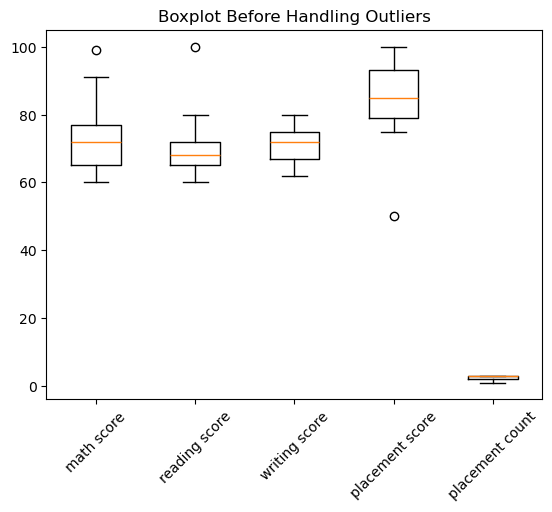

In [17]:
plt.boxplot(df[outlier_columns])
plt.xticks(range(1, len(outlier_columns) + 1), outlier_columns, rotation=45)
plt.title("Boxplot Before Handling Outliers")
plt.show()

In [18]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_limit) | (data[column] > upper_limit)]

    return outliers

In [19]:
for col in outlier_columns:
    print("\nOutliers in", col)
    print(detect_outliers_iqr(df, col)[[col]])


Outliers in math score
   math score
3        99.0

Outliers in reading score
   reading score
6          100.0

Outliers in writing score
Empty DataFrame
Columns: [writing score]
Index: []

Outliers in placement score
   placement score
5             50.0

Outliers in placement count
Empty DataFrame
Columns: [placement count]
Index: []


In [20]:
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

In [21]:
for col in outlier_columns:
    cap_outliers_iqr(df, col)

print("Outliers handled using capping method")
df.head()

Outliers handled using capping method


,gender,math score,reading score,writing score,placement score,club join year,placement count,region
0,Male,66.0,65.0,76.0,97.0,2020.0,3.0,Pune
1,Female,91.0,70.0,76.0,76.0,2019.0,2.0,Baramati
2,Female,72.0,66.0,75.0,79.0,2019.0,2.0,Satara
3,Male,95.0,75.0,67.0,84.0,2018.0,2.0,Karad
4,Female,62.0,65.0,68.0,87.0,2018.0,3.0,Mulshi


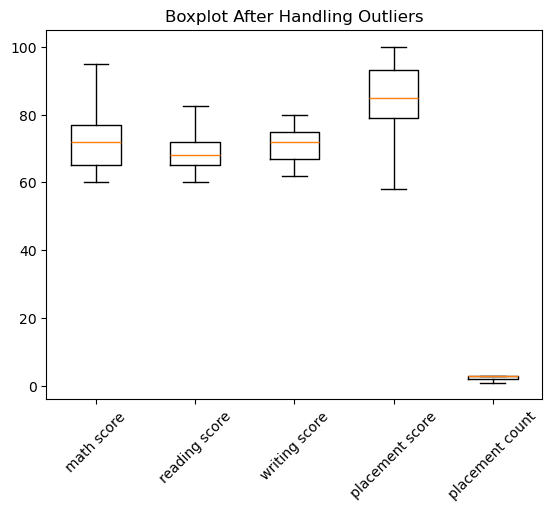

In [22]:
plt.boxplot(df[outlier_columns])
plt.xticks(range(1, len(outlier_columns) + 1), outlier_columns, rotation=45)
plt.title("Boxplot After Handling Outliers")
plt.show()

In [23]:
skew_values = df[outlier_columns].skew()

print("Skewness of numeric columns:")
print(skew_values)

Skewness of numeric columns:
math score         0.833134
reading score      0.621587
writing score     -0.277652
placement score   -0.577531
placement count   -0.535473
dtype: float64


In [24]:
transform_column = skew_values.abs().idxmax()

print("Column selected for transformation:")
print(transform_column)

Column selected for transformation:
math score


In [25]:
print("Skewness before transformation:")
print(df[transform_column].skew())

Skewness before transformation:
0.8331337806409628


In [26]:
if df[transform_column].min() <= 0:
    shifted_data = df[transform_column] - df[transform_column].min() + 1
else:
    shifted_data = df[transform_column]

df[transform_column + "_Log"] = np.log1p(shifted_data)

print("Log transformation applied successfully")

Log transformation applied successfully


In [27]:
print("Skewness after transformation:")
print(df[transform_column + "_Log"].skew())

Skewness after transformation:
0.5433554052447981


In [28]:
df.head()

,gender,math score,reading score,writing score,placement score,club join year,placement count,region,math score_Log
0,Male,66.0,65.0,76.0,97.0,2020.0,3.0,Pune,4.204693
1,Female,91.0,70.0,76.0,76.0,2019.0,2.0,Baramati,4.521789
2,Female,72.0,66.0,75.0,79.0,2019.0,2.0,Satara,4.290459
3,Male,95.0,75.0,67.0,84.0,2018.0,2.0,Karad,4.564348
4,Female,62.0,65.0,68.0,87.0,2018.0,3.0,Mulshi,4.143135


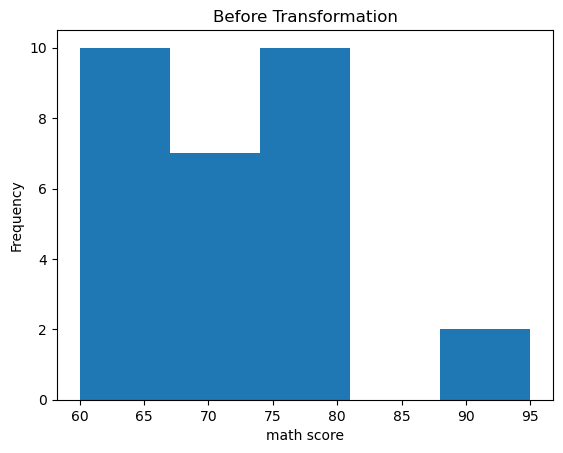

In [29]:
plt.hist(df[transform_column], bins=5)
plt.title("Before Transformation")
plt.xlabel(transform_column)
plt.ylabel("Frequency")
plt.show()

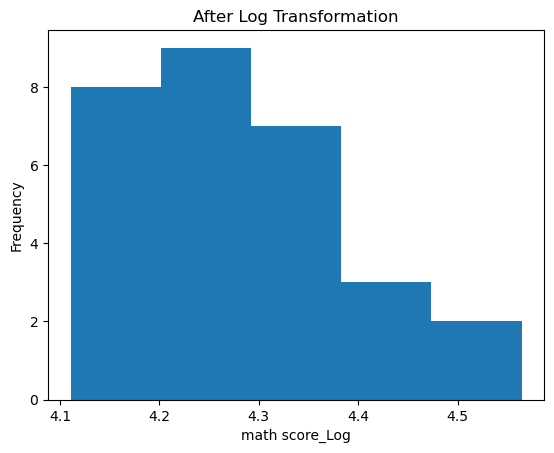

In [30]:
plt.hist(df[transform_column + "_Log"], bins=5)
plt.title("After Log Transformation")
plt.xlabel(transform_column + "_Log")
plt.ylabel("Frequency")
plt.show()

In [31]:
df.to_csv("cleaned_academic_performance.csv", index=False)

print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully
